In [1]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import json
import time
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from groq import Groq

In [ ]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# Validate API key
if GROQ_API_KEY == "your_api_key_here":
    raise ValueError("⚠️ Please set your GROQ_API_KEY! Either:\n"
                     "1. Replace 'your_api_key_here' with your actual key, OR\n"
                     "2. Set environment variable: export GROQ_API_KEY='your_key'")

try:
    client = Groq(api_key=GROQ_API_KEY)
except Exception as e:
    raise ValueError(f"❌ Failed to initialize Groq client: {e}")

MODEL_NAME = "llama-3.1-8b-instant"
SAMPLE_SIZE = 50
DELAY_BETWEEN_REQUESTS = 6.0
MAX_RETRIES = 5
BASE_RETRY_DELAY = 5
MAX_REVIEW_LENGTH = 100
MAX_RESPONSE_TOKENS = 150

In [4]:
def call_groq_api(prompt, technique_name, request_number=0):
    """
    Make API call to Groq with comprehensive error handling
    Returns: dict with 'success', 'predicted_stars', 'explanation', or 'error'
    """
    for attempt in range(MAX_RETRIES):
        try:
            # Make API call
            chat_completion = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=MODEL_NAME,
                temperature=0.3,
                max_tokens=MAX_RESPONSE_TOKENS,
            )

            response_text = chat_completion.choices[0].message.content.strip()

            # Try to extract JSON
            if '{' in response_text and '}' in response_text:
                start_idx = response_text.find('{')
                end_idx = response_text.rfind('}') + 1
                json_str = response_text[start_idx:end_idx]

                # Clean common JSON issues
                json_str = json_str.replace('\n', ' ').replace('\r', '')

                try:
                    result = json.loads(json_str)
                except json.JSONDecodeError:
                    # Try to fix common issues
                    json_str = json_str.replace("'", '"')  # Single to double quotes
                    try:
                        result = json.loads(json_str)
                    except json.JSONDecodeError as e:
                        return {
                            'success': False,
                            'error': f'JSON parse error: {str(e)[:100]}',
                            'raw_response': response_text[:200]
                        }

                # Flexible field name matching
                stars_field = None
                explanation_field = None

                # Check for stars field
                for field in ['predicted_stars', 'stars', 'rating', 'star_rating']:
                    if field in result:
                        stars_field = field
                        break

                # Check for explanation field
                for field in ['explanation', 'reason', 'reasoning', 'why', 'analysis']:
                    if field in result:
                        explanation_field = field
                        break

                if stars_field and explanation_field:
                    try:
                        stars = int(result[stars_field])
                        if 1 <= stars <= 5:
                            return {
                                'success': True,
                                'predicted_stars': stars,
                                'explanation': str(result[explanation_field])
                            }
                        else:
                            return {
                                'success': False,
                                'error': f'Stars out of range: {stars}',
                                'raw_response': response_text[:200]
                            }
                    except (ValueError, TypeError) as e:
                        return {
                            'success': False,
                            'error': f'Invalid stars value: {result.get(stars_field)}',
                            'raw_response': response_text[:200]
                        }
                else:
                    return {
                        'success': False,
                        'error': f'Missing required fields. Found: {list(result.keys())}',
                        'raw_response': response_text[:200]
                    }
            else:
                return {
                    'success': False,
                    'error': 'No JSON found in response',
                    'raw_response': response_text[:200]
                }

        except Exception as e:
            error_str = str(e)

            # Handle rate limiting
            if '429' in error_str or 'rate limit' in error_str.lower():
                wait_time = BASE_RETRY_DELAY * (2 ** attempt)
                print(f"\n⚠️ Rate limit hit at request #{request_number}!")
                print(f"   Waiting {wait_time} seconds before retry {attempt+1}/{MAX_RETRIES}...")
                time.sleep(wait_time)
                continue

            # Handle other errors
            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️ Error on attempt {attempt+1}: {error_str[:100]}")
                print(f"   Retrying in 2 seconds...")
                time.sleep(2)
                continue

            # Final failure
            return {
                'success': False,
                'error': f'API error after {MAX_RETRIES} attempts: {error_str[:150]}',
                'raw_response': ''
            }

    return {
        'success': False,
        'error': f'Max retries ({MAX_RETRIES}) exceeded',
        'raw_response': ''
    }

In [5]:
class OptimizedPromptingTechniques:

    @staticmethod
    def truncate_review(review_text, max_words=MAX_REVIEW_LENGTH):
        """Safely truncate review to save tokens"""
        if not isinstance(review_text, str):
            review_text = str(review_text)

        words = review_text.split()
        if len(words) > max_words:
            return ' '.join(words[:max_words]) + "..."
        return review_text

    @staticmethod
    def few_shot_learning(review_text):
        """TECHNIQUE 1: Few-Shot Learning"""
        review_short = OptimizedPromptingTechniques.truncate_review(review_text, 80)

        prompt = f"""Rate this review on a scale of 1-5 stars based on these examples:

Example 1: "Amazing food, great service!" → 5 stars (very positive)
Example 2: "Good but pricey" → 3 stars (mixed feelings)
Example 3: "Terrible, never again" → 1 star (very negative)

Now rate this review:
"{review_short}"

You MUST respond with ONLY a JSON object in exactly this format with no other text:
{{"predicted_stars": 3, "explanation": "brief reason"}}"""
        return prompt

    @staticmethod
    def chain_of_thought(review_text):
        """TECHNIQUE 2: Chain-of-Thought Reasoning"""
        review_short = OptimizedPromptingTechniques.truncate_review(review_text, 80)

        prompt = f"""Analyze this review step by step and rate it 1-5 stars.

Review: "{review_short}"

Steps to follow:
1. Identify the overall sentiment (positive, negative, or neutral)
2. Assess the intensity (mild, moderate, or strong)
3. Determine the appropriate star rating (1=worst, 5=best)

You MUST respond with ONLY a JSON object in exactly this format with no other text:
{{"predicted_stars": 3, "explanation": "your step-by-step reasoning"}}"""
        return prompt

    @staticmethod
    def hybrid_approach(review_text):
        """TECHNIQUE 3: Hybrid (Examples + Reasoning)"""
        review_short = OptimizedPromptingTechniques.truncate_review(review_text, 80)

        prompt = f"""Use these examples as guidance, then think through your rating:

Examples: "Great!" → 5 stars | "Okay" → 3 stars | "Bad" → 1 star

Review: "{review_short}"

Think: Is this positive or negative? How strong is the emotion?

You MUST respond with ONLY a JSON object in exactly this format with no other text:
{{"predicted_stars": 3, "explanation": "your reasoning"}}"""
        return prompt

    @staticmethod
    def role_based_prompting(review_text):
        """TECHNIQUE 4: Role-Based Prompting"""
        review_short = OptimizedPromptingTechniques.truncate_review(review_text, 80)

        prompt = f"""You are an expert Yelp review analyst. Rate this review using the standard 1-5 star scale:

5 stars = Customer is delighted/thrilled
4 stars = Customer is satisfied/pleased
3 stars = Customer is neutral/has mixed feelings
2 stars = Customer is disappointed/unhappy
1 star = Customer is angry/very upset

Review: "{review_short}"

You MUST respond with ONLY a JSON object in exactly this format with no other text:
{{"predicted_stars": 3, "explanation": "your professional assessment"}}"""
        return prompt

    @staticmethod
    def zero_shot_structured(review_text):
        """TECHNIQUE 5: Zero-Shot with Structure"""
        review_short = OptimizedPromptingTechniques.truncate_review(review_text, 80)

        prompt = f"""Rate this review on a 1-5 star scale:

Rating scale:
1 star = Terrible experience
2 stars = Poor/disappointing
3 stars = Average/okay
4 stars = Good/satisfied
5 stars = Excellent/amazing

Review: "{review_short}"

You MUST respond with ONLY a JSON object in exactly this format with no other text:
{{"predicted_stars": 3, "explanation": "brief reason for rating"}}"""
        return prompt

In [7]:
def evaluate_technique_safe(df, technique_func, technique_name, sample_size=50):
    """Evaluate a single prompting technique with comprehensive error handling"""

    print(f"\n{'='*80}")
    print(f"📊 Evaluating: {technique_name}")
    print(f"{'='*80}")
    print(f"📊 Total samples: {sample_size}")
    print(f"⏱️  Delay between requests: {DELAY_BETWEEN_REQUESTS} seconds")
    print(f"⏰ Estimated time: ~{(sample_size * DELAY_BETWEEN_REQUESTS) / 60:.1f} minutes")
    print(f"{'='*80}\n")

    df_sample = df.head(sample_size).copy()
    results = []
    json_valid_count = 0
    correct_predictions = 0
    total_abs_error = 0
    start_time = time.time()

    for idx, (orig_idx, row) in enumerate(df_sample.iterrows(), 1):
        # Calculate progress metrics
        elapsed = time.time() - start_time
        avg_time_per_request = elapsed / idx if idx > 0 else 0
        remaining = (sample_size - idx) * avg_time_per_request
        current_accuracy = (correct_predictions / idx * 100) if idx > 0 else 0

        # Display progress
        print(f"Processing {idx}/{sample_size} | "
              f"Elapsed: {elapsed/60:.1f}m | "
              f"Remaining: ~{remaining/60:.1f}m | "
              f"Accuracy: {current_accuracy:.1f}% | "
              f"Valid JSON: {json_valid_count}/{idx}",
              end='\r')

        # Generate prompt
        try:
            prompt = technique_func(row['text'])
        except Exception as e:
            print(f"\n⚠️ Error generating prompt for sample {idx}: {e}")
            results.append({
                'review_text': str(row['text'])[:100] + "...",
                'actual_stars': row['stars'],
                'predicted_stars': None,
                'explanation': '',
                'json_valid': False,
                'error': f'Prompt generation error: {str(e)[:100]}'
            })
            continue

        # Call API
        response = call_groq_api(prompt, technique_name, request_number=idx)

        # Record result
        result = {
            'review_text': str(row['text'])[:100] + "...",
            'actual_stars': int(row['stars']),
            'predicted_stars': None,
            'explanation': '',
            'json_valid': response['success'],
            'error': response.get('error', '')
        }

        if response['success']:
            json_valid_count += 1
            predicted = response['predicted_stars']
            result['predicted_stars'] = predicted
            result['explanation'] = response['explanation']

            if predicted == row['stars']:
                correct_predictions += 1
            total_abs_error += abs(predicted - row['stars'])

        results.append(result)

        # Wait between requests
        time.sleep(DELAY_BETWEEN_REQUESTS)

        # Save progress periodically
        if idx % 20 == 0:
            try:
                progress_df = pd.DataFrame(results)
                progress_df.to_csv(f'{technique_name}_progress.csv', index=False)
                print(f"\n💾 Progress saved at {idx} samples" + " "*50)
            except Exception as e:
                print(f"\n⚠️ Failed to save progress: {e}")

    print("\n")

    # Calculate final metrics
    total_samples = len(results)
    accuracy = (correct_predictions / total_samples) * 100 if total_samples > 0 else 0
    json_validity = (json_valid_count / total_samples) * 100 if total_samples > 0 else 0
    mae = total_abs_error / json_valid_count if json_valid_count > 0 else 0

    # Print results
    print(f"\n{'='*80}")
    print(f"✅ {technique_name} - RESULTS:")
    print(f"{'='*80}")
    print(f"   Accuracy: {accuracy:.2f}% ({correct_predictions}/{total_samples})")
    print(f"   JSON Validity: {json_validity:.2f}% ({json_valid_count}/{total_samples})")
    print(f"   Mean Absolute Error: {mae:.2f}")
    print(f"   Total Time: {(time.time() - start_time)/60:.1f} minutes")
    print(f"{'='*80}\n")

    # Save final results
    try:
        results_df = pd.DataFrame(results)
        results_df.to_csv(f'{technique_name}_final.csv', index=False)
        print(f"💾 Final results saved to: {technique_name}_final.csv\n")
    except Exception as e:
        print(f"⚠️ Failed to save final results: {e}\n")

    return {
        'technique': technique_name,
        'accuracy': accuracy,
        'json_validity': json_validity,
        'mae': mae,
        'correct': correct_predictions,
        'total': total_samples,
        'detailed_results': results
    }


In [8]:
def create_visualization(all_results):
    """Create comprehensive visualization of results"""

    print("\n📈 Generating visualization...")

    try:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Prompting Techniques Comparison - {MODEL_NAME} ({SAMPLE_SIZE} Samples)',
                     fontsize=16, fontweight='bold')

        techniques_names = [r['technique'] for r in all_results.values()]
        accuracies = [r['accuracy'] for r in all_results.values()]
        json_validities = [r['json_validity'] for r in all_results.values()]
        maes = [r['mae'] for r in all_results.values()]

        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

        # 1. Accuracy comparison
        axes[0, 0].bar(range(len(techniques_names)), accuracies, color=colors)
        axes[0, 0].set_xticks(range(len(techniques_names)))
        axes[0, 0].set_xticklabels(techniques_names, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Accuracy (%)', fontsize=12)
        axes[0, 0].set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylim(0, 100)
        for i, v in enumerate(accuracies):
            axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

        # 2. JSON validity
        axes[0, 1].bar(range(len(techniques_names)), json_validities, color=colors)
        axes[0, 1].set_xticks(range(len(techniques_names)))
        axes[0, 1].set_xticklabels(techniques_names, rotation=45, ha='right')
        axes[0, 1].set_ylabel('JSON Validity (%)', fontsize=12)
        axes[0, 1].set_title('JSON Validity Rate', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylim(0, 100)
        for i, v in enumerate(json_validities):
            axes[0, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

        # 3. MAE comparison
        axes[1, 0].bar(range(len(techniques_names)), maes, color=colors)
        axes[1, 0].set_xticks(range(len(techniques_names)))
        axes[1, 0].set_xticklabels(techniques_names, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Mean Absolute Error', fontsize=12)
        axes[1, 0].set_title('MAE (Lower is Better)', fontsize=14, fontweight='bold')
        for i, v in enumerate(maes):
            axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

        # 4. Confusion matrix for best technique
        best_accuracy = max(all_results.values(), key=lambda x: x['accuracy'])
        best_results = best_accuracy['detailed_results']
        actuals = [r['actual_stars'] for r in best_results if r['predicted_stars'] is not None]
        predicted = [r['predicted_stars'] for r in best_results if r['predicted_stars'] is not None]

        if len(actuals) > 0:
            cm = confusion_matrix(actuals, predicted, labels=[1, 2, 3, 4, 5])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
                        xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5])
            axes[1, 1].set_xlabel('Predicted Stars', fontsize=12)
            axes[1, 1].set_ylabel('Actual Stars', fontsize=12)
            axes[1, 1].set_title(f'Confusion Matrix - {best_accuracy["technique"]}',
                                fontsize=14, fontweight='bold')
        else:
            axes[1, 1].text(0.5, 0.5, 'No valid predictions for confusion matrix',
                           ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout()
        plt.savefig('prompting_techniques_results.png', dpi=300, bbox_inches='tight')
        print("✅ Visualization saved: prompting_techniques_results.png")
        plt.show()

    except Exception as e:
        print(f"⚠️ Error creating visualization: {e}")


In [10]:
def main():
    """Main execution function"""

    print("="*80)
    print("🚀 RATING PREDICTION VIA PROMPTING - ROBUST VERSION")
    print("="*80)

    # Load and validate data
    print("\n📂 Loading data...")

    if not os.path.exists('yelp.csv'):
        raise FileNotFoundError(
            "❌ yelp.csv not found!\n"
            "Please ensure the file is in the same directory as this script."
        )

    try:
        df_reviews = pd.read_csv('/content/yelp.csv')
        print(f"✅ Loaded CSV with {len(df_reviews)} rows")
    except Exception as e:
        raise Exception(f"❌ Error reading CSV: {e}")

    # Validate required columns
    if 'text' not in df_reviews.columns or 'stars' not in df_reviews.columns:
        raise ValueError(
            "❌ CSV must contain 'text' and 'stars' columns!\n"
            f"Found columns: {list(df_reviews.columns)}"
        )

    # Clean data
    print("🧹 Cleaning data...")
    df_clean = df_reviews[['text', 'stars']].copy()
    df_clean = df_clean.dropna()
    df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
    df_clean = df_clean.dropna()
    df_clean['stars'] = df_clean['stars'].astype(int)
    df_clean = df_clean[(df_clean['stars'] >= 1) & (df_clean['stars'] <= 5)]
    df_clean = df_clean[df_clean['text'].str.len() > 10]

    print(f"✅ Cleaned data: {len(df_clean)} valid reviews")

    if len(df_clean) < SAMPLE_SIZE:
        print(f"⚠️ Warning: Only {len(df_clean)} reviews available, using all of them")
        sample_size = len(df_clean)
    else:
        sample_size = SAMPLE_SIZE

    # Sample data
    df_sample = df_clean.sample(n=sample_size, random_state=42)

    # Initialize techniques
    techniques = OptimizedPromptingTechniques()

    # Display configuration
    print("\n" + "="*80)
    print("⚙️  CONFIGURATION")
    print("="*80)
    print(f"🤖 Model: {MODEL_NAME}")
    print(f"📊 Sample size: {sample_size}")
    print(f"📝 Max tokens per response: {MAX_RESPONSE_TOKENS}")
    print(f"✂️  Reviews truncated to: {MAX_REVIEW_LENGTH} words")
    print(f"⏱️  Delay between requests: {DELAY_BETWEEN_REQUESTS} seconds")
    print(f"⏰ Estimated total time: ~{(sample_size * DELAY_BETWEEN_REQUESTS * 5)/60:.1f} minutes")
    print("="*80)

    # Run all techniques
    all_results = {}

    techniques_list = [
        ('few_shot', techniques.few_shot_learning, "1_Few_Shot"),
        ('chain_of_thought', techniques.chain_of_thought, "2_Chain_of_Thought"),
        ('hybrid', techniques.hybrid_approach, "3_Hybrid"),
        ('role_based', techniques.role_based_prompting, "4_Role_Based"),
        ('zero_shot', techniques.zero_shot_structured, "5_Zero_Shot"),
    ]

    for idx, (key, func, name) in enumerate(techniques_list, 1):
        print(f"\n\n🎯 TECHNIQUE {idx} OF 5: {name}")

        try:
            all_results[key] = evaluate_technique_safe(
                df_sample, func, name, sample_size=sample_size
            )
            print(f"✅ Technique {idx} complete!")
        except Exception as e:
            print(f"❌ Error evaluating {name}: {e}")
            all_results[key] = {
                'technique': name,
                'accuracy': 0,
                'json_validity': 0,
                'mae': 0,
                'correct': 0,
                'total': sample_size,
                'detailed_results': []
            }

        if idx < 5:
            print("⏸️  Cooling down for 10 seconds...")
            time.sleep(10)

    # Generate comparison table
    print("\n\n" + "="*80)
    print("📊 FINAL COMPARISON TABLE")
    print("="*80 + "\n")

    comparison_df = pd.DataFrame([
        {
            'Technique': result['technique'],
            'Accuracy (%)': f"{result['accuracy']:.2f}",
            'JSON Valid (%)': f"{result['json_validity']:.2f}",
            'MAE': f"{result['mae']:.2f}",
            'Correct/Total': f"{result['correct']}/{result['total']}"
        }
        for result in all_results.values()
    ])

    print(comparison_df.to_string(index=False))

    try:
        comparison_df.to_csv('final_comparison.csv', index=False)
        print("\n💾 Comparison saved: final_comparison.csv")
    except Exception as e:
        print(f"\n⚠️ Failed to save comparison: {e}")

    # Identify winners
    valid_results = [r for r in all_results.values() if r['json_validity'] > 0]

    if valid_results:
        best_accuracy = max(valid_results, key=lambda x: x['accuracy'])
        best_mae = min(valid_results, key=lambda x: x['mae'] if x['mae'] > 0 else float('inf'))
        best_json = max(valid_results, key=lambda x: x['json_validity'])

        print(f"\n{'='*80}")
        print("🏆 WINNERS")
        print(f"{'='*80}")
        print(f"🎯 Best Accuracy: {best_accuracy['technique']} ({best_accuracy['accuracy']:.2f}%)")
        print(f"📉 Best MAE: {best_mae['technique']} (MAE: {best_mae['mae']:.2f})")
        print(f"✅ Best JSON Validity: {best_json['technique']} ({best_json['json_validity']:.2f}%)")
        print(f"{'='*80}")
    else:
        print("\n⚠️ No valid results to compare")

    # Create visualization
    if valid_results:
        create_visualization(all_results)

    print("\n✅ ALL EVALUATIONS COMPLETE!")
    print("\n📁 Generated files:")
    print("   - *_progress.csv (progress saves for each technique)")
    print("   - *_final.csv (final results for each technique)")
    print("   - final_comparison.csv (comparison table)")
    print("   - prompting_techniques_results.png (visualization)")
    print("\n" + "="*80)

🚀 RATING PREDICTION VIA PROMPTING - ROBUST VERSION

📂 Loading data...
✅ Loaded CSV with 10000 rows
🧹 Cleaning data...
✅ Cleaned data: 9987 valid reviews

⚙️  CONFIGURATION
🤖 Model: llama-3.1-8b-instant
📊 Sample size: 50
📝 Max tokens per response: 150
✂️  Reviews truncated to: 100 words
⏱️  Delay between requests: 6.0 seconds
⏰ Estimated total time: ~25.0 minutes


🎯 TECHNIQUE 1 OF 5: 1_Few_Shot

📊 Evaluating: 1_Few_Shot
📊 Total samples: 50
⏱️  Delay between requests: 6.0 seconds
⏰ Estimated time: ~5.0 minutes


💾 Progress saved at 20 samples                                                  

💾 Progress saved at 40 samples                                                  



✅ 1_Few_Shot - RESULTS:
   Accuracy: 32.00% (16/50)
   JSON Validity: 100.00% (50/50)
   Mean Absolute Error: 0.82
   Total Time: 5.2 minutes

💾 Final results saved to: 1_Few_Shot_final.csv

✅ Technique 1 complete!
⏸️  Cooling down for 10 seconds...


🎯 TECHNIQUE 2 OF 5: 2_Chain_of_Thought

📊 Evaluating: 2_Chain_of_

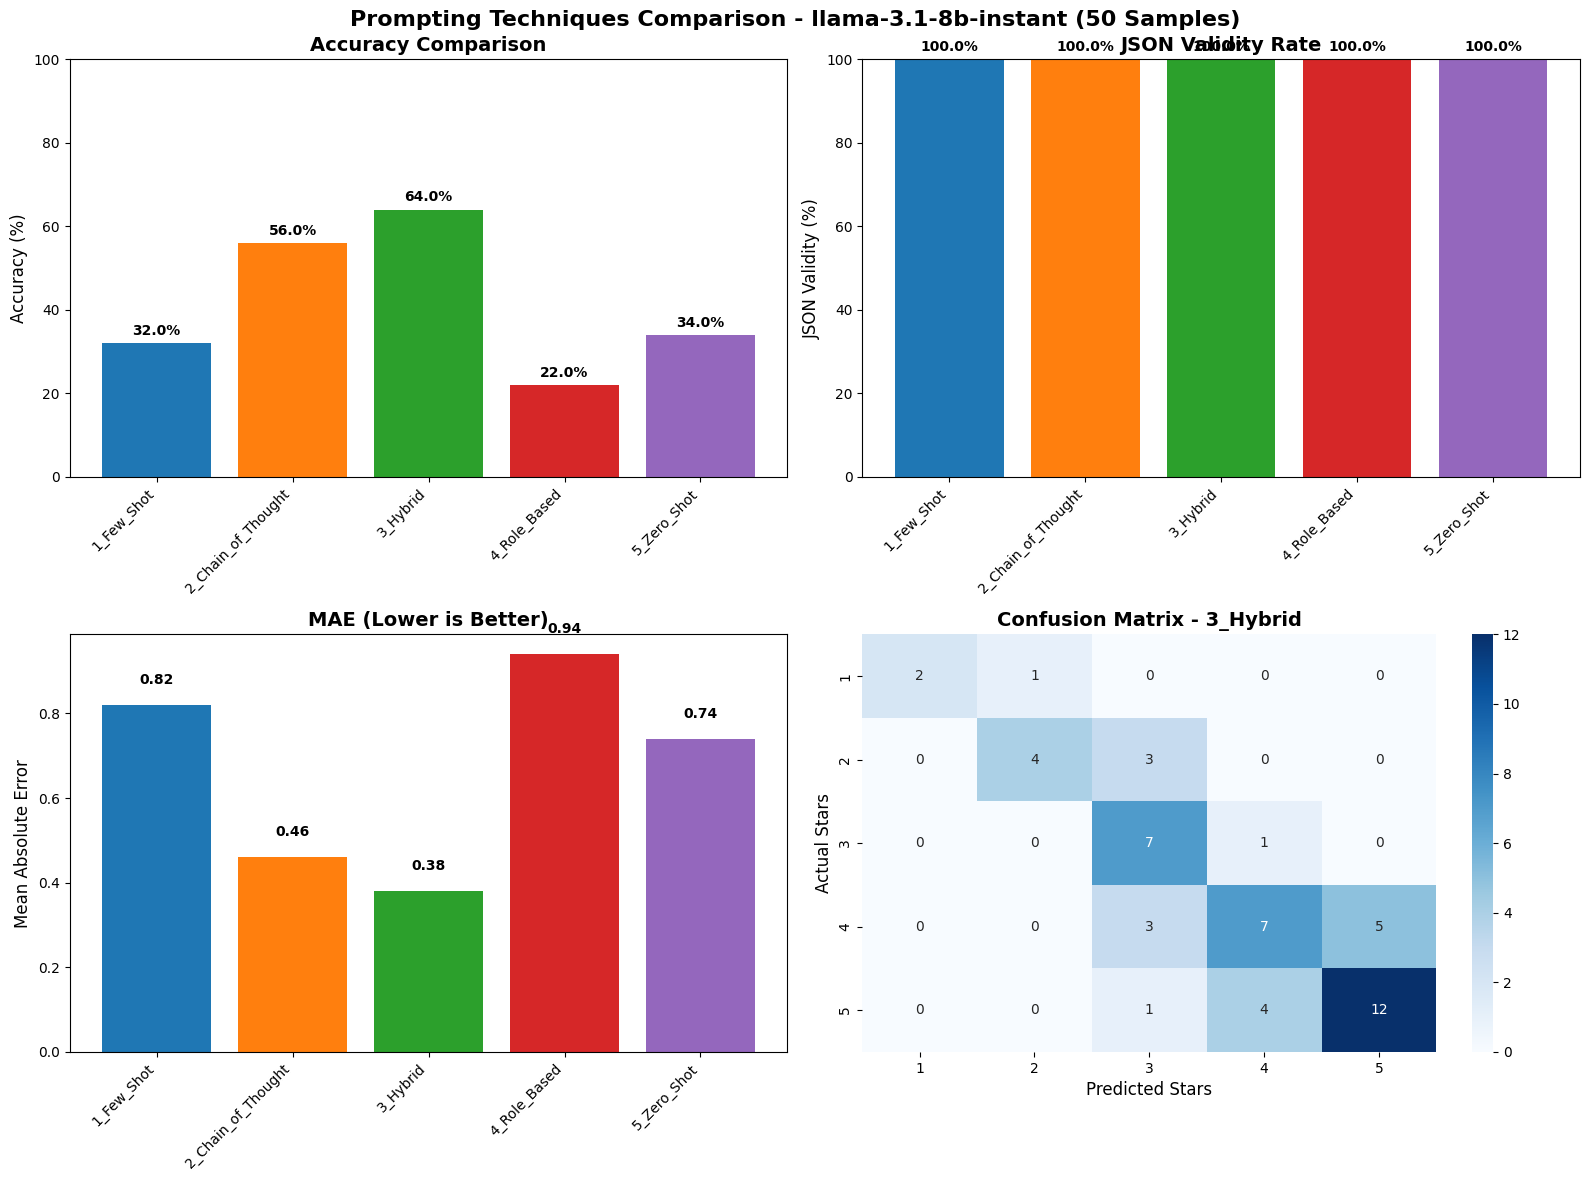


✅ ALL EVALUATIONS COMPLETE!

📁 Generated files:
   - *_progress.csv (progress saves for each technique)
   - *_final.csv (final results for each technique)
   - final_comparison.csv (comparison table)
   - prompting_techniques_results.png (visualization)



In [11]:
if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⚠️ Execution interrupted by user")
    except Exception as e:
        print(f"\n\n❌ FATAL ERROR: {e}")
        raise